# IRT: human vs. model vs. combined

Compares item difficulty estimated three ways -- from real human responses only, from the
37-candidate model cascade only, and from both combined -- fit with both Rasch (MLE) and
Bayesian (NUTS) IRT. Answers: do model responses track real human-derived difficulty well
enough to use as a cheap proxy?

Data: `question_difficulty_with_irt.ipynb` (human) + `run_answerer_cascade.py`/
`score_cascade_results.py` (model cascade, `cascade_results_all_scored.json`). See
`question_difficulty/docs/cascade_experiment_report.md` for the cascade results themselves.

## Contents

0. [Imports and paths](#imports)
1. [Load the 6 difficulty estimates](#load)
2. [Correlation matrix](#correlation)
3. [Scatter: human vs. model vs. combined](#scatter)
4. [Sanity check vs. the difficulty tag](#sanity-check)
5. [Findings](#findings)

<a id="imports"></a>
## 0. Imports and paths

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

NOTEBOOKS_DIR = Path.cwd()
SCRIPTS_DIR = NOTEBOOKS_DIR.parent / "scripts"
assert SCRIPTS_DIR.exists()

<a id="load"></a>
## 1. Load the 6 difficulty estimates

Each is item_id -> difficulty (higher = harder). Rasch difficulties come from `fit_rasch()` (MLE point estimate); Bayesian from `fit_bayesian_irt()` (posterior mean, 3PL with a fixed 0.25 guessing floor). "model" = the 37-candidate answerer cascade (question_difficulty/docs/cascade_experiment_report.md); "combined" = human buckets + model candidates fit together as one set of "persons".

In [2]:
DIFFICULTY_FILES = {
    ("human", "rasch"): NOTEBOOKS_DIR / "irt_rasch_difficulty_cache.json",
    ("human", "bayesian"): SCRIPTS_DIR / "irt_bayesian_human_only_difficulty.json",
    ("model", "rasch"): SCRIPTS_DIR / "irt_rasch_model_only_difficulty.json",
    ("model", "bayesian"): SCRIPTS_DIR / "irt_bayesian_model_only_difficulty.json",
    ("combined", "rasch"): SCRIPTS_DIR / "irt_rasch_combined_difficulty.json",
    ("combined", "bayesian"): SCRIPTS_DIR / "irt_bayesian_combined_difficulty.json",
}

difficulty = {key: json.loads(path.read_text()) for key, path in DIFFICULTY_FILES.items()}
for (source, method), d in difficulty.items():
    print(f"{source:10s} {method:10s} {len(d)} items")

# Common items across all 6 (all should be the same 1296, but intersect to be safe)
common_items = set.intersection(*(set(d.keys()) for d in difficulty.values()))
print(f"\ncommon items across all 6: {len(common_items)}")

human      rasch      1296 items
human      bayesian   1296 items
model      rasch      1296 items
model      bayesian   1296 items
combined   rasch      1296 items
combined   bayesian   1296 items

common items across all 6: 1296


<a id="correlation"></a>
## 2. Correlation matrix

Pearson correlation between every pair of the 6 difficulty estimates, restricted to the common items. High human-vs-model correlation would mean the cheap model cascade tracks real human difficulty well; low would mean it doesn't.

In [3]:
items_sorted = sorted(common_items)
labels = [f"{s}_{m}" for s, m in difficulty]
matrix = np.zeros((len(labels), len(labels)))
for i, key_i in enumerate(difficulty):
    vals_i = np.array([difficulty[key_i][it] for it in items_sorted])
    for j, key_j in enumerate(difficulty):
        vals_j = np.array([difficulty[key_j][it] for it in items_sorted])
        matrix[i, j] = pearsonr(vals_i, vals_j)[0]

corr_df = pd.DataFrame(matrix, index=labels, columns=labels).round(3)
corr_df

,human_rasch,human_bayesian,model_rasch,model_bayesian,combined_rasch,combined_bayesian
human_rasch,1.000,0.998,0.528,0.458,0.599,0.557
human_bayesian,0.998,1.000,0.532,0.460,0.602,0.558
model_rasch,0.528,0.532,1.000,0.914,0.996,0.918
model_bayesian,0.458,0.460,0.914,1.000,0.906,0.993
combined_rasch,0.599,0.602,0.996,0.906,1.000,0.919
combined_bayesian,0.557,0.558,0.918,0.993,0.919,1.000


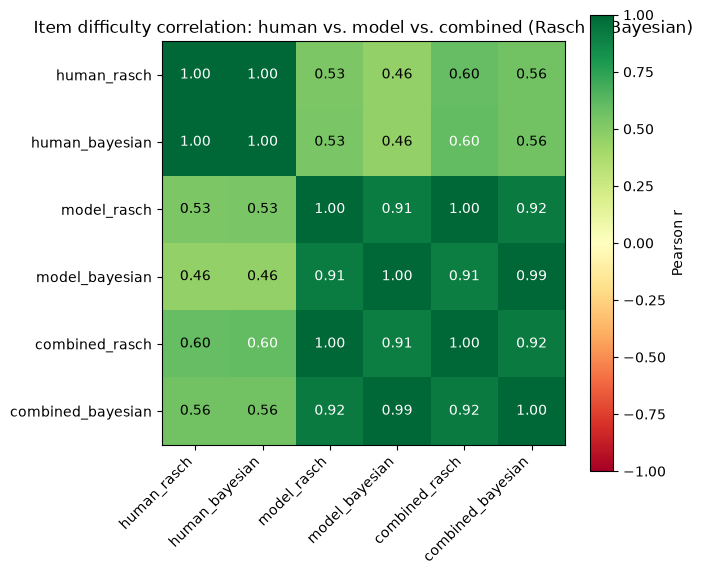

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{matrix[i,j]:.2f}", ha="center", va="center",
                 color="white" if abs(matrix[i,j]) > 0.6 else "black")
plt.colorbar(im, ax=ax, label="Pearson r")
plt.title("Item difficulty correlation: human vs. model vs. combined (Rasch + Bayesian)")
plt.tight_layout()
plt.show()

<a id="scatter"></a>
## 3. Scatter: human vs. model vs. combined

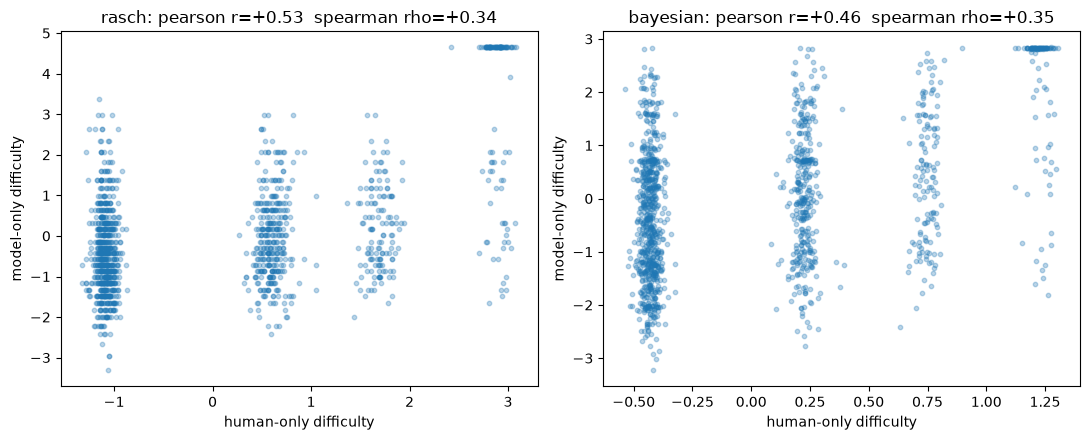

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, method in zip(axes, ["rasch", "bayesian"]):
    human_vals = np.array([difficulty[("human", method)][it] for it in items_sorted])
    model_vals = np.array([difficulty[("model", method)][it] for it in items_sorted])
    r, _ = pearsonr(human_vals, model_vals)
    rho, _ = spearmanr(human_vals, model_vals)
    ax.scatter(human_vals, model_vals, alpha=0.3, s=10)
    ax.set_xlabel("human-only difficulty")
    ax.set_ylabel("model-only difficulty")
    ax.set_title(f"{method}: pearson r={r:+.2f}  spearman rho={rho:+.2f}")

plt.tight_layout()
plt.show()

<a id="sanity-check"></a>
## 4. Sanity check vs. the difficulty tag

Does model-only difficulty reproduce the same source/level pattern the human-only fit showed (RACE-High clearly harder than RACE-Middle; OneStopQA Adv barely different from Ele)?

In [6]:
item_meta_raw = json.loads((NOTEBOOKS_DIR / "irt_item_meta_cache.json").read_text())
item_meta = {k: tuple(v) for k, v in item_meta_raw.items()}

rows = []
for (source, method), d in difficulty.items():
    by_tag = {}
    for it in items_sorted:
        if it not in item_meta:
            continue
        tag = item_meta[it]
        by_tag.setdefault(tag, []).append(d[it])
    for tag, vals in sorted(by_tag.items()):
        rows.append({"estimate": f"{source}_{method}", "source": tag[0], "difficulty_tag": tag[1],
                     "mean_b": sum(vals) / len(vals), "n": len(vals)})

pd.DataFrame(rows).pivot_table(index=["source", "difficulty_tag"], columns="estimate", values="mean_b").round(3)

estimate                combined_bayesian  combined_rasch  human_bayesian  \
source  difficulty_tag                                                      
Onestop Adv                        -0.193          -0.257          -0.048   
        Ele                        -0.321          -0.419          -0.082   
RACE    High                        0.575           0.666           0.239   
        Middle                     -0.061          -0.077          -0.109   

estimate                human_rasch  model_bayesian  model_rasch  
source  difficulty_tag                                            
Onestop Adv                  -0.139          -0.203       -0.235  
        Ele                  -0.225          -0.328       -0.398  
RACE    High                  0.543           0.554        0.668  
        Middle               -0.291          -0.023       -0.022

<a id="findings"></a>
## 5. Findings

- Human vs. model difficulty correlation: **r=0.46-0.53** (moderate, not strong) across Rasch/Bayesian. Model cascade is a decent but imperfect proxy for real human difficulty.
- Rasch vs. Bayesian agree closely within the same person-set (human: r=0.998, model: r=0.914) -- the choice of fitting method barely matters; what matters is whose responses went in.
- Combined correlates more with human (r=0.60) than model-only does (r=0.53) -- expected, since combined includes the human data itself -- but is still dominated by the model signal (r=0.90-1.00 vs. model-only), since 37 model "persons" outnumber 24 human buckets.
- Source/tag pattern **diverges** by estimate: humans find RACE-Middle clearly easier than average (b=-0.29), models barely do (b=-0.02) -- models and humans disagree on what makes RACE-Middle easy. Conversely, models separate OneStopQA Adv/Ele MORE than humans did (model gap=0.16 vs. human gap=0.09).
- Takeaway: don't treat model-cascade difficulty as a drop-in replacement for human difficulty -- moderate correlation overall, and it visibly diverges on RACE-Middle and OneStopQA Adv/Ele specifically.